In [1]:
import sys
from typing import Any

def get_size(obj: object, default: Any = -1) -> int:
    """Computes how much memory storage is being used by input obj in [bytes]."""
    return sys.getsizeof(obj, default=default)

def print_size(obj: object, bit: bool = True) -> None:
    size, unit = get_size(obj), 'bytes'
    if bit:
        size *= 8
        unit = 'bit'
    print(
        f'Obj ({type(obj)}) memory storage: {size} {unit}'
    )
    return None

In [2]:
import numpy as np

a = np.int32(10)
b = 10.0

a_list = [1, 0, 3]
a_dict = {'a': 1, 'b': [3, 4]}
b_list = [1, 0.0, 'str', {'a': 1, 'b': [3, 4]}]

n = 5000

c_np32 = np.ones(n, dtype=np.int32)
d_np32 = np.ones((n, n), dtype=np.int32)
e_np32 = np.ones(n, dtype=np.float32)
f_np32 = np.ones((n, n), dtype=np.float32)

c_np64 = np.ones(n, dtype=np.int64)
d_np64 = np.ones((n, n), dtype=np.int64)
e_np64 = np.ones(n, dtype=np.float64)
f_np64 = np.ones((n, n), dtype=np.float64)

record = np.rec.array(
    obj=10 * [
        ('s0', 's0', 10.0, 50.0, 1e4, np.random.randint(0, 10, 513), np.random.randint(0, 10, 512)),
    ],
    dtype=[
        ('ID', '16U'), ('NAME', '20U'), ('RA', np.float32), ('DEC', np.float32), ('AVG_FLUX', np.float32),
        ('ENERGY', np.float32, 513), ('SPECTRUM', np.float32, 512),
    ],
)


container: tuple[Any, ...] = (
a, b, a_list, a_dict, b_list, c_np32, d_np32, e_np32, f_np32, c_np64, d_np64, e_np64, f_np64, record,
)

for item in container:
    print_size(item)

Obj (<class 'numpy.int32'>) memory storage: 224 bit
Obj (<class 'float'>) memory storage: 192 bit
Obj (<class 'list'>) memory storage: 704 bit
Obj (<class 'dict'>) memory storage: 1472 bit
Obj (<class 'list'>) memory storage: 704 bit
Obj (<class 'numpy.ndarray'>) memory storage: 160896 bit
Obj (<class 'numpy.ndarray'>) memory storage: 800001024 bit
Obj (<class 'numpy.ndarray'>) memory storage: 160896 bit
Obj (<class 'numpy.ndarray'>) memory storage: 800001024 bit
Obj (<class 'numpy.ndarray'>) memory storage: 320896 bit
Obj (<class 'numpy.ndarray'>) memory storage: 1600001024 bit
Obj (<class 'numpy.ndarray'>) memory storage: 320896 bit
Obj (<class 'numpy.ndarray'>) memory storage: 1600001024 bit
Obj (<class 'numpy.rec.recarray'>) memory storage: 1152 bit


In [7]:
from typing import NamedTuple

class Event(NamedTuple):
    ID: int
    SUBID: int
    SDD_ID: int
    HSDD_ID: int
    TIME: float
    X_HSDD: float
    Y_HSDD: float
    X: float
    Y: float
    ENERGY: float
    SIGMA: float
    X_ERR: float
    Y_ERR: float
    ENERGY_ERR: float
    SIGMA_ERR: float


phs: int = 1
event: Event = Event(
    1000, 1000, 1000, 1000, 1000.0, 1000.0, 1000.0, 1000.0,
    1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0,
)

phs_list: np.recarray = np.rec.array(
    obj=int(phs) * [event],
    dtype=[
        ('ID', np.uint64), ('SUBID', np.uint64), ('SDD_ID', np.uint64), ('HSDD_ID', np.uint64),
        ('TIME', np.float64), ('X_HSDD', np.float64), ('Y_HSDD', np.float64), ('X', np.float64),
        ('Y', np.float64), ('ENERGY', np.float64), ('SIGMA', np.float64), ('X_ERR', np.float64),
        ('Y_ERR', np.float64), ('ENERGY_ERR', np.float64), ('SIGMA_ERR', np.float64),
    ],
)

print_size(event)
print_size(phs_list)

len(phs_list)

Obj (<class '__main__.Event'>) memory storage: 1280 bit
Obj (<class 'numpy.rec.recarray'>) memory storage: 1152 bit


1

In [8]:
np.save('/home/edoardo/Desktop/arr.npy', phs_list)

In [9]:
1152 * phs / 8

144.0

In [10]:
from numpy.typing import NDArray
import numpy as np

from bloodmoon.mask import CodedMaskCamera, codedmask


# directory path
base_path: str = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations"
#base_path: str = "/mnt/d/PhD_AASS/Coding/Images_fits"

# load camera framework
MASK_FITS: str = "wfm_mask_NTHT_20260129_CORRECTED.fits"
UPS_X, UPS_Y = 2, 1
wfm: CodedMaskCamera = codedmask(f'{base_path}/{MASK_FITS}', UPS_X, UPS_Y)

In [13]:
wfm.shape_detector, wfm.shape_mask, wfm.shape_sky

((308, 1264), (522, 2080), (829, 3343))

In [29]:
from scipy.fft import fft2

cov = np.array(
    [
        [1.0, 0.5],
        [0.5, 1.0],
    ]
)

a = np.random.multivariate_normal([0.0, 0.0], cov, 50 ** 2)

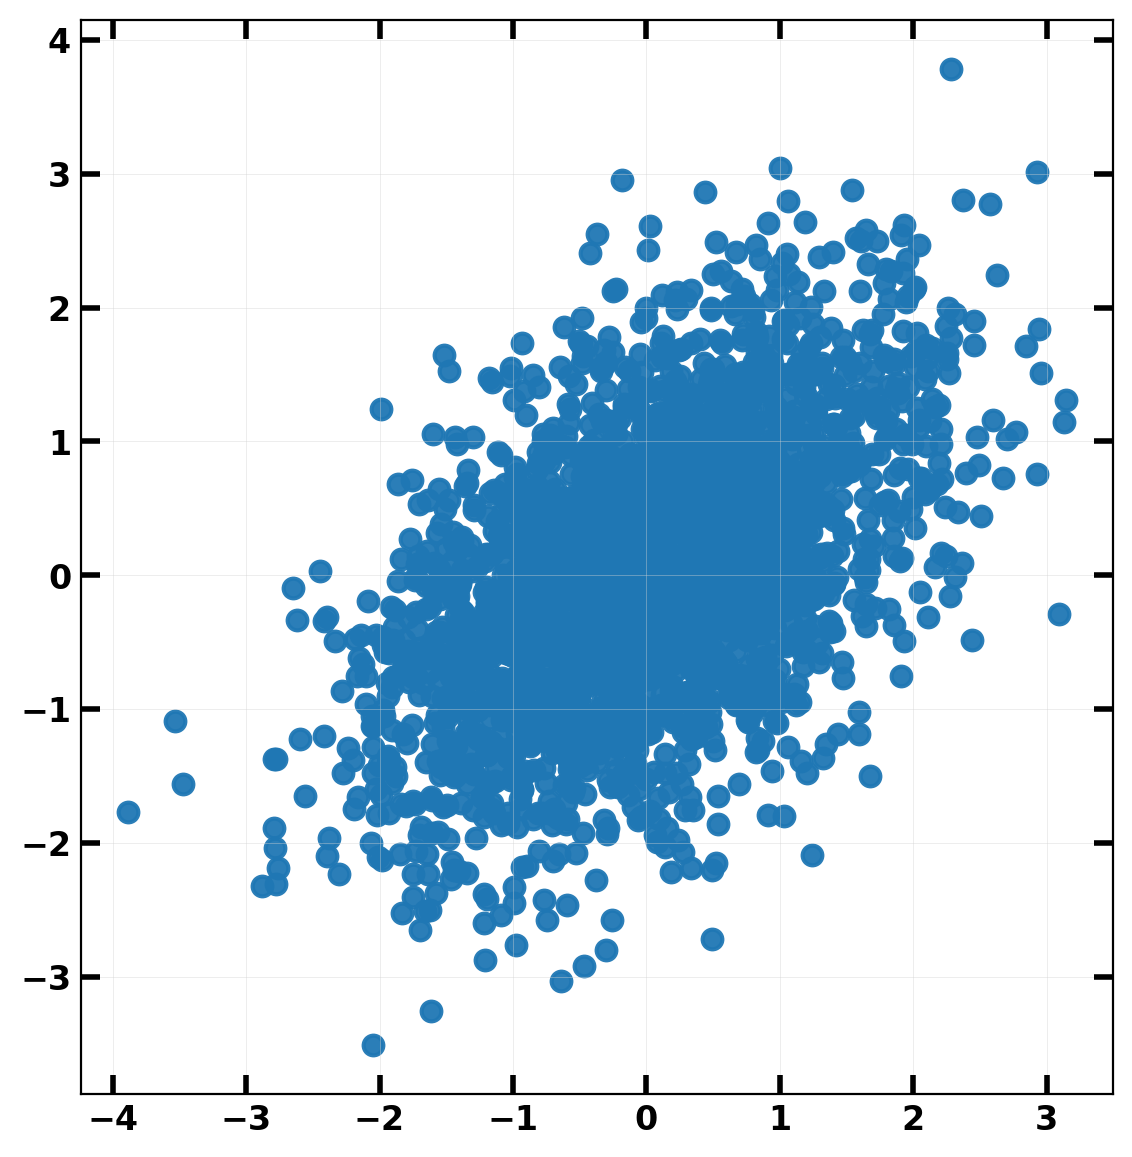

In [30]:
import darksun as ds

ds.plot(
    ds.map4plot(a[:, 0], '', style='scatter', x=a[:, 1])
)